In [ ]:
# CELL 1 — Mount Drive and load all results
from google.colab import drive
drive.mount('/content/drive')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('/content/drive/MyDrive/CS271/wing_results.json', 'r') as f:
    wing = json.load(f)

with open('/content/drive/MyDrive/CS271/svm_cnn_results.json', 'r') as f:
    svm_cnn = json.load(f)

with open('/content/drive/MyDrive/CS271/distilbert_results.json', 'r') as f:
    distilbert = json.load(f)

print('All files loaded!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files loaded!


In [ ]:
# CELL 2 — Combine all models into unified dicts
all_clean = {}
all_manip = {}
all_adv   = {}
all_roc   = {}

# Wing's models
all_clean.update(wing['clean'])
all_manip.update(wing['manip'])
all_adv.update(wing['adversarial'])
all_roc.update(wing['roc_curves'])

# SVM and CNN
all_clean.update(svm_cnn['clean'])
all_manip.update(svm_cnn['manip'])
all_adv.update(svm_cnn['adversarial'])
all_roc.update(svm_cnn['roc_curves'])

# DistilBERT
all_clean['DistilBERT'] = distilbert['clean']
all_manip['DistilBERT'] = distilbert['manip']
all_adv['DistilBERT']   = distilbert['adversarial']
all_roc['DistilBERT']   = distilbert['roc_curves']

print('Clean models:      ', list(all_clean.keys()))
print('Manip models:      ', list(all_manip.keys()))
print('Adversarial models:', list(all_adv.keys()))

Clean models:       ['Naive Bayes', 'Logistic Regression', 'Naive Bayes (Robust)', 'Logistic Regression (Robust)', 'MLP', 'SVM', 'CNN', 'SVM (Normal)', 'DistilBERT']
Manip models:       ['Naive Bayes', 'Logistic Regression', 'Naive Bayes (Robust)', 'Logistic Regression (Robust)', 'MLP', 'SVM', 'CNN', 'SVM (Normal)', 'DistilBERT']
Adversarial models: ['Naive Bayes (Robust)', 'Logistic Regression (Robust)', 'MLP', 'SVM', 'CNN', 'SVM (Normal)', 'DistilBERT']


In [ ]:
# CELL 3 — Master comparison table
=metric_cols = ['Accuracy', 'F1', 'AUC', 'EER']

clean_df = pd.DataFrame(all_clean).T[metric_cols]
manip_df = pd.DataFrame(all_manip).T[metric_cols]
adv_df   = pd.DataFrame(all_adv).T[metric_cols]

print('\n' + '='*65)
print('  CLEAN EMAILS')
print('='*65)
print(clean_df.round(4).to_string())

print('\n' + '='*65)
print('  CHAR SUBSTITUTION')
print('='*65)
print(manip_df.round(4).to_string())

print('\n' + '='*65)
print('  ADVERSARIAL ATTACK')
print('='*65)
print(adv_df.round(4).to_string())


  CLEAN EMAILS
                              Accuracy      F1     AUC     EER
Naive Bayes                     0.9369  0.9317  0.9842  0.0571
Logistic Regression             0.9718  0.9695  0.9970  0.0259
Naive Bayes (Robust)            0.9362  0.9304  0.9829  0.0626
Logistic Regression (Robust)    0.9681  0.9651  0.9959  0.0340
MLP                             0.9740  0.9713  0.9980  0.0231
SVM                             0.9763  0.9739  0.9979  0.0231
CNN                             0.9785  0.9764  0.9976  0.0218
SVM (Normal)                    0.9822  0.9805  0.9987  0.0177
DistilBERT                      0.9926  0.9918  0.9996  0.0068

  CHAR SUBSTITUTION
                              Accuracy      F1     AUC     EER
Naive Bayes                     0.6417  0.6430  0.7330  0.3456
Logistic Regression             0.5920  0.6813  0.7998  0.2585
Naive Bayes (Robust)            0.9318  0.9277  0.9829  0.0680
Logistic Regression (Robust)    0.9770  0.9750  0.9972  0.0272
MLP               

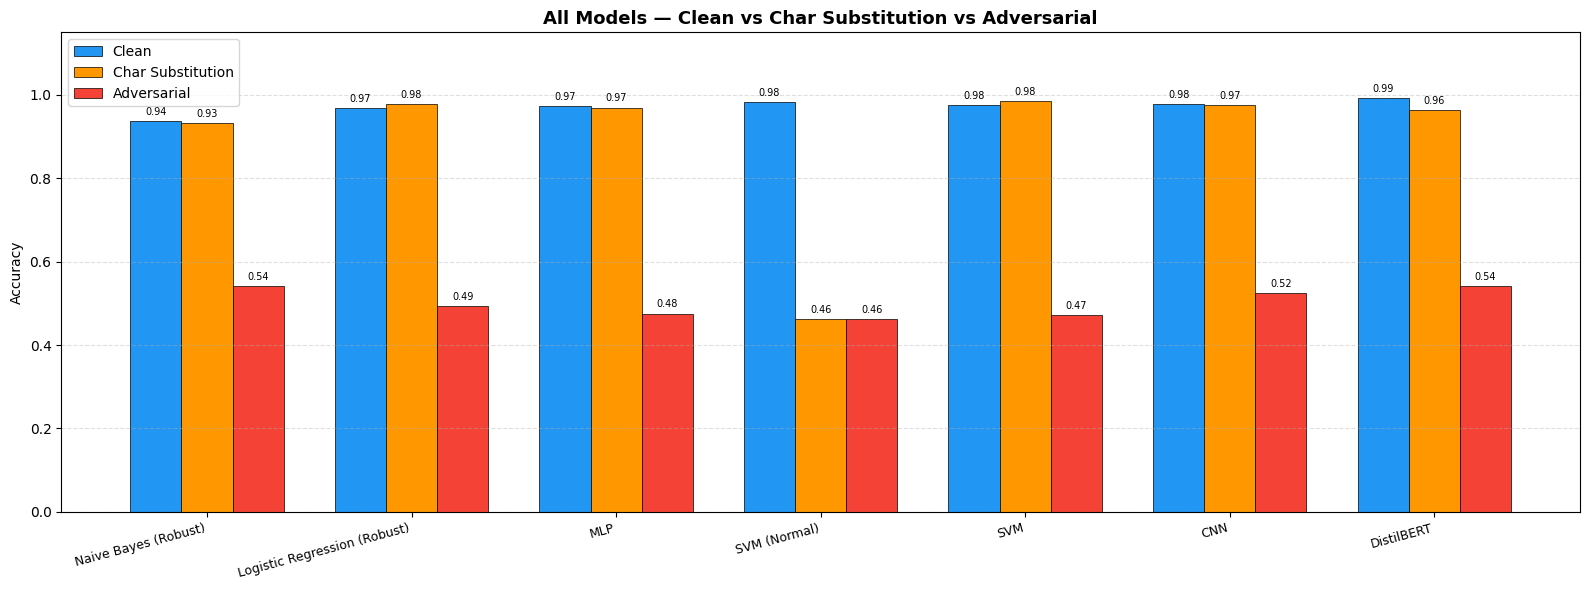

In [ ]:
# CELL 4 — Combined accuracy bar chart all models
# Define model order
model_order = [
    'Naive Bayes', 'Naive Bayes (Robust)',
    'Logistic Regression', 'Logistic Regression (Robust)',
    'MLP', 'SVM (Normal)', 'SVM', 'CNN', 'DistilBERT'
]
model_order = [m for m in model_order if m in all_clean and m in all_manip and m in all_adv]

clean_acc = [all_clean[m]['Accuracy'] for m in model_order]
manip_acc = [all_manip[m]['Accuracy'] for m in model_order]
adv_acc   = [all_adv[m]['Accuracy']   for m in model_order]

x     = np.arange(len(model_order))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - width, clean_acc, width, label='Clean',             color='#2196F3', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x,         manip_acc, width, label='Char Substitution', color='#FF9800', edgecolor='black', linewidth=0.5)
b3 = ax.bar(x + width, adv_acc,   width, label='Adversarial',       color='#F44336', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.15)
ax.set_title('All Models — Clean vs Char Substitution vs Adversarial', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bars in [b1, b2, b3]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS271/combined_plots/combined_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()

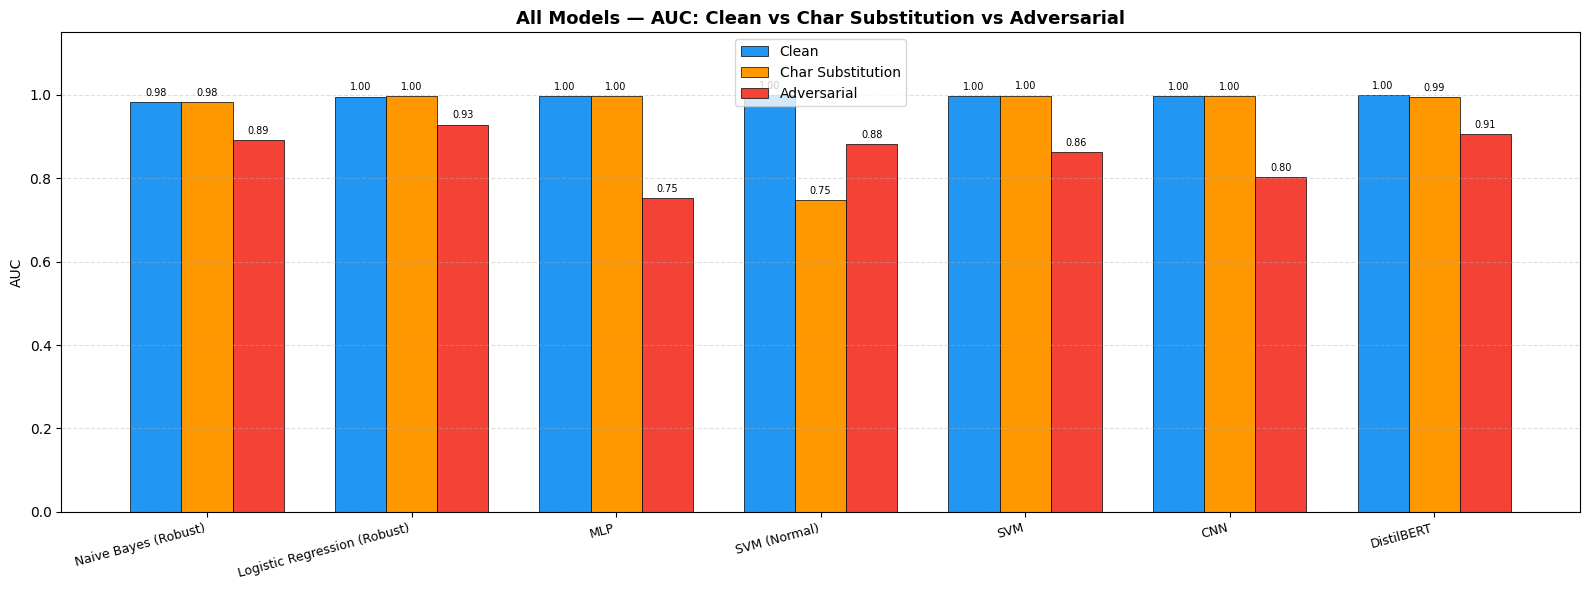

In [ ]:
# CELL 5 — Combined AUC bar chart
clean_auc = [all_clean[m]['AUC'] for m in model_order]
manip_auc = [all_manip[m]['AUC'] for m in model_order]
adv_auc   = [all_adv[m]['AUC']   for m in model_order]

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - width, clean_auc, width, label='Clean',             color='#2196F3', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x,         manip_auc, width, label='Char Substitution', color='#FF9800', edgecolor='black', linewidth=0.5)
b3 = ax.bar(x + width, adv_auc,   width, label='Adversarial',       color='#F44336', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('AUC')
ax.set_ylim(0, 1.15)
ax.set_title('All Models — AUC: Clean vs Char Substitution vs Adversarial', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bars in [b1, b2, b3]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS271/combined_plots/combined_auc_bar.png', dpi=150, bbox_inches='tight')
plt.show()

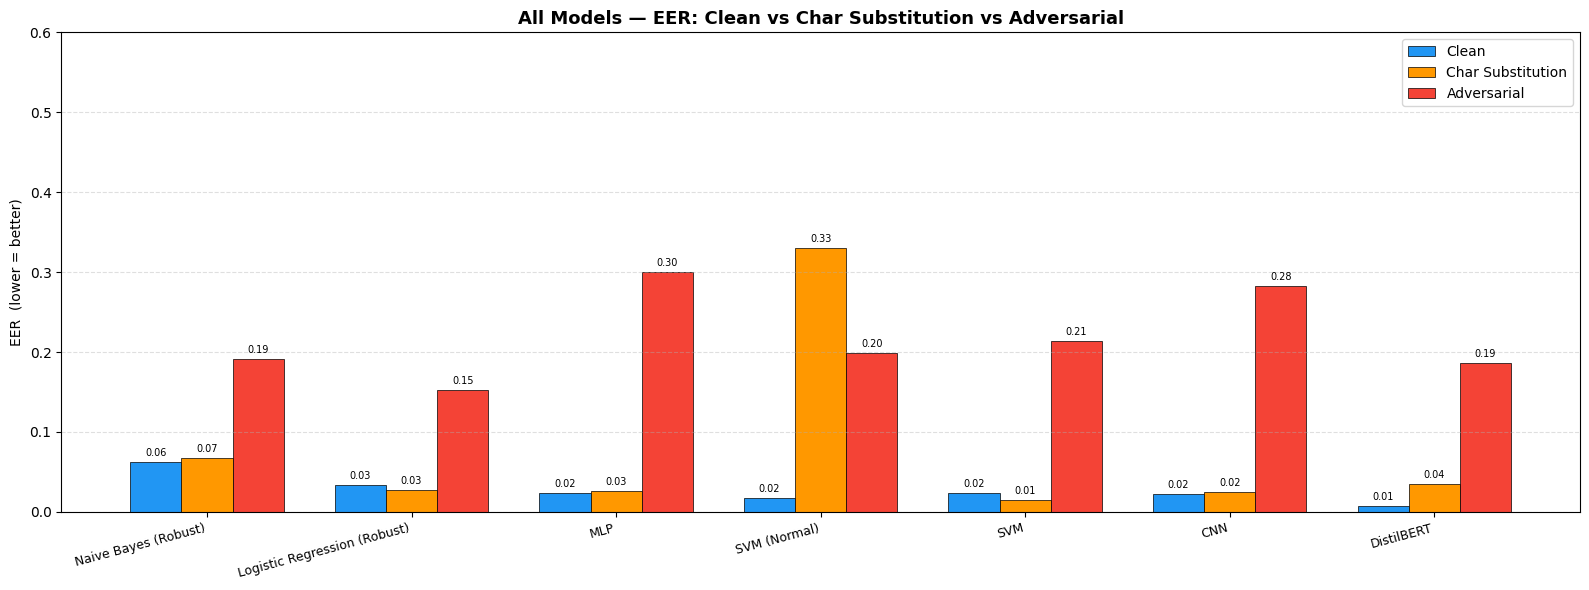

In [ ]:
# CELL 6 — Combined EER bar chart
clean_eer = [all_clean[m]['EER'] for m in model_order]
manip_eer = [all_manip[m]['EER'] for m in model_order]
adv_eer   = [all_adv[m]['EER']   for m in model_order]

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - width, clean_eer, width, label='Clean',             color='#2196F3', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x,         manip_eer, width, label='Char Substitution', color='#FF9800', edgecolor='black', linewidth=0.5)
b3 = ax.bar(x + width, adv_eer,   width, label='Adversarial',       color='#F44336', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('EER  (lower = better)')
ax.set_ylim(0, 0.6)
ax.set_title('All Models — EER: Clean vs Char Substitution vs Adversarial', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bars in [b1, b2, b3]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS271/combined_plots/combined_eer_bar.png', dpi=150, bbox_inches='tight')
plt.show()

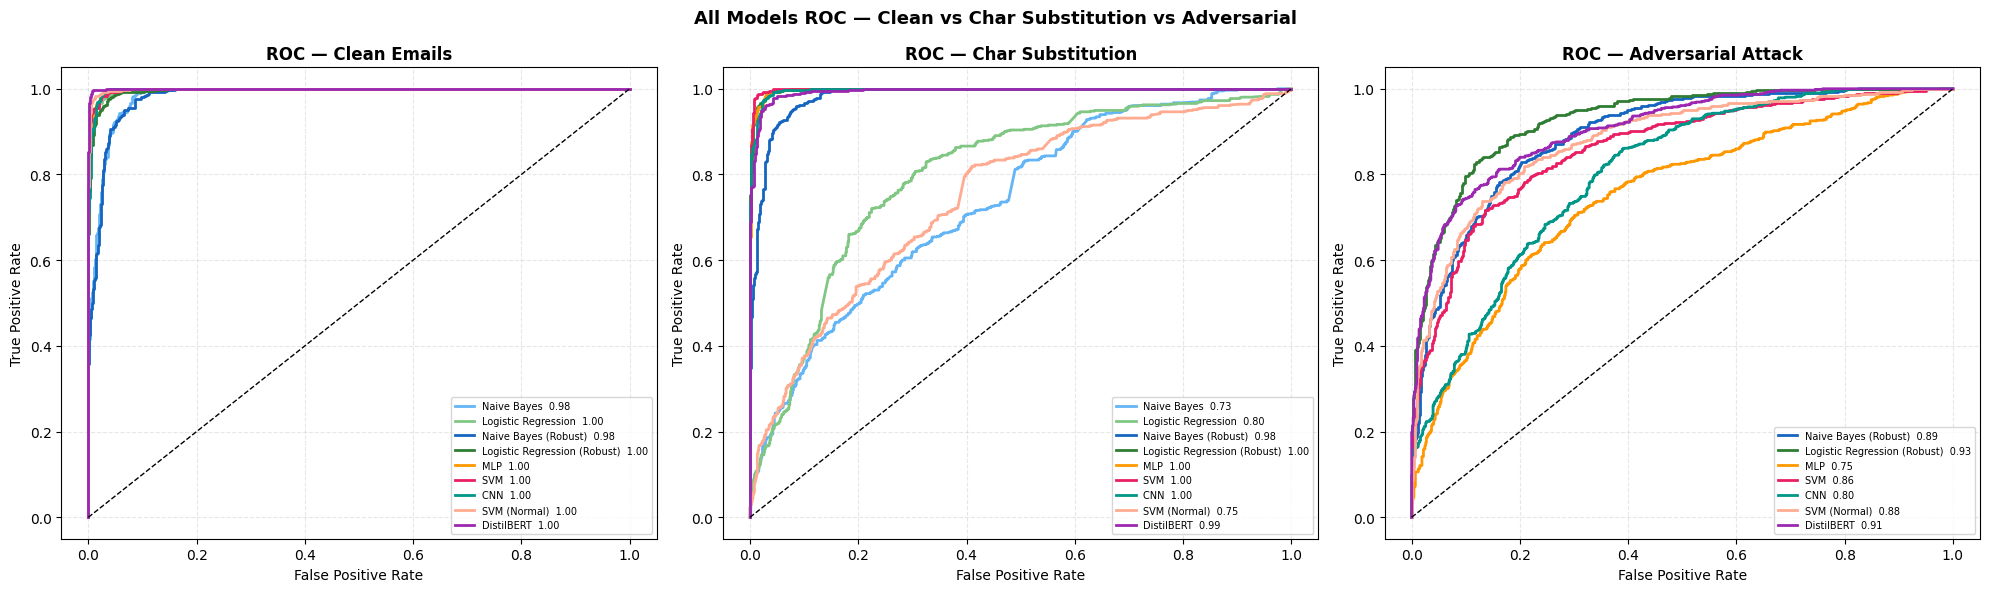

In [ ]:
# CELL 7 — Combined ROC curves all 3 conditions
import os
os.makedirs('/content/drive/MyDrive/CS271/combined_plots/', exist_ok=True)

colors = {
    'Naive Bayes':                  '#64B5F6',
    'Naive Bayes (Robust)':         '#1565C0',
    'Logistic Regression':          '#81C784',
    'Logistic Regression (Robust)': '#2E7D32',
    'MLP':                          '#FF9800',
    'SVM (Normal)':                 '#FFAB91',
    'SVM':                          '#E91E63',
    'CNN':                          '#009688',
    'DistilBERT':                   '#9C27B0',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
splits = ['clean', 'manip', 'adversarial']
titles = ['Clean Emails', 'Char Substitution', 'Adversarial Attack']

for ax, split, title in zip(axes, splits, titles):
    for model_name, split_data in all_roc.items():
        if split in split_data and model_name in colors:
            fpr     = split_data[split]['fpr']
            tpr     = split_data[split]['tpr']
            roc_auc = split_data[split]['auc']
            ax.plot(fpr, tpr,
                    label=f'{model_name}  {roc_auc:.2f}',
                    color=colors[model_name],
                    linewidth=2)
    ax.plot([0,1],[0,1],'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {title}', fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('All Models ROC — Clean vs Char Substitution vs Adversarial', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS271/combined_plots/combined_roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

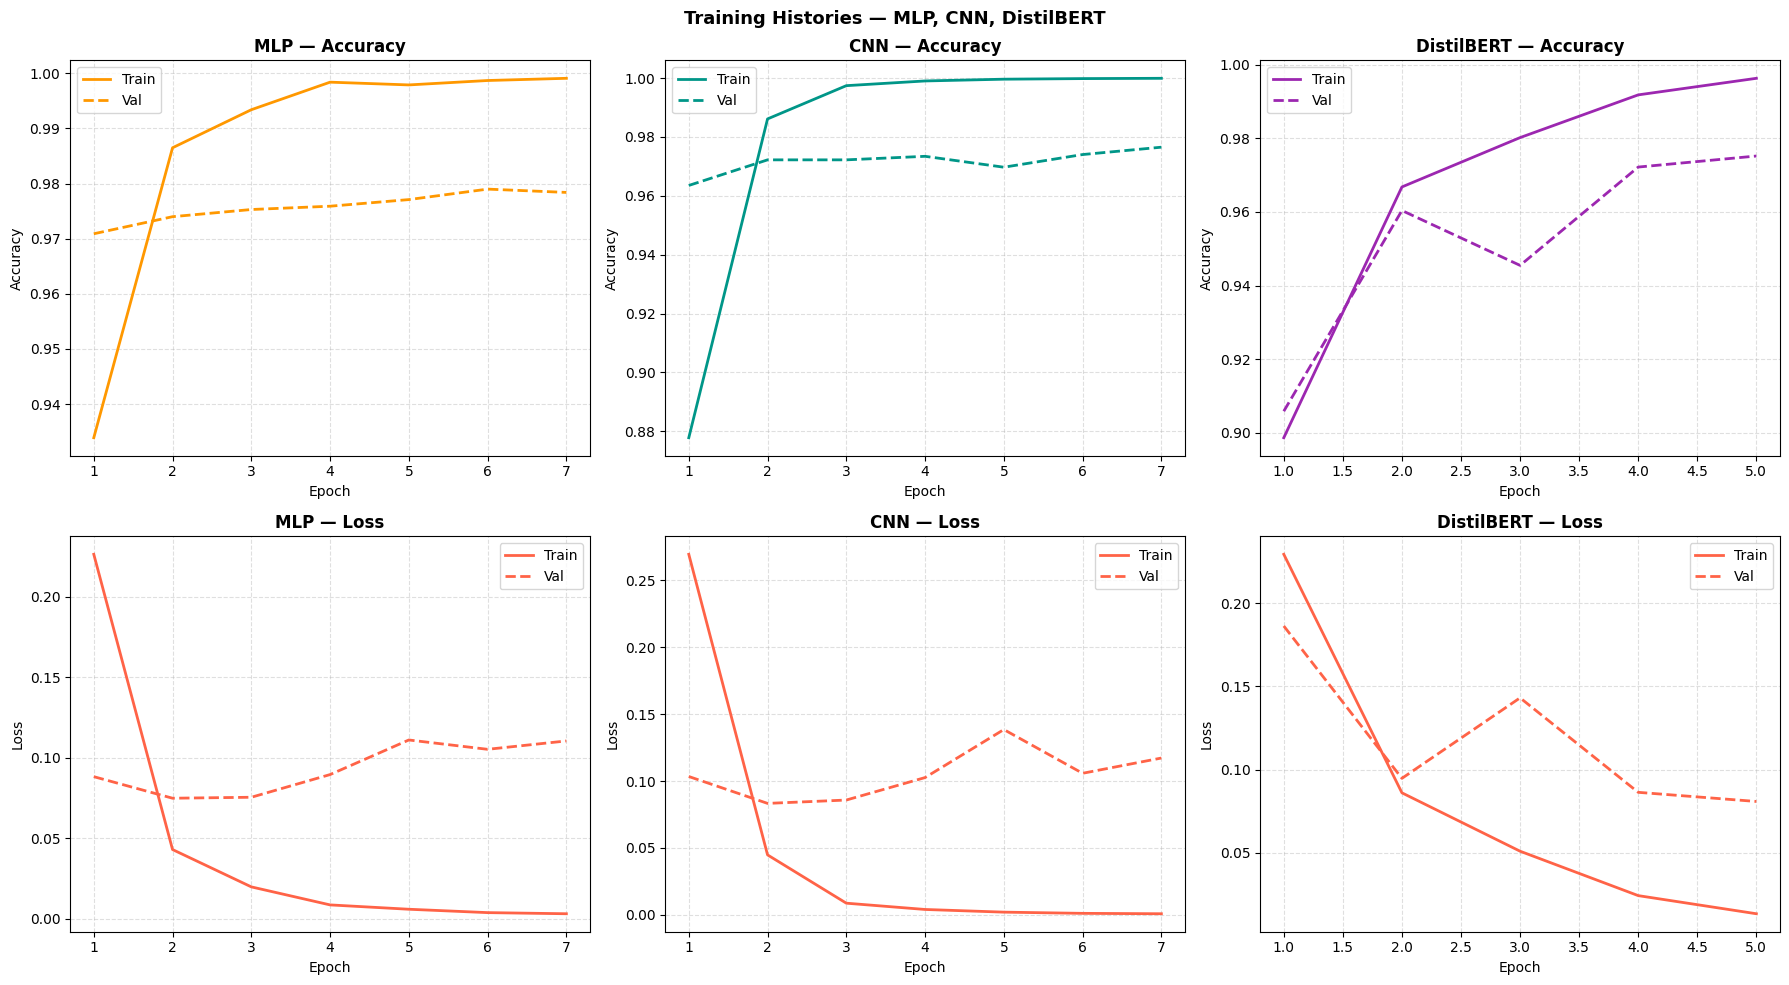

In [ ]:
# CELL 8 — Training histories: MLP, CNN, DistilBERT

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

histories = {
    'MLP':        wing['training_history']['MLP'],
    'CNN':        svm_cnn['training_history']['CNN'],
    'DistilBERT': distilbert['training_history']
}

model_colors = {'MLP': '#FF9800', 'CNN': '#009688', 'DistilBERT': '#9C27B0'}

for col, (model_name, hist) in enumerate(histories.items()):
    epochs = range(1, len(hist['accuracy']) + 1)
    color  = model_colors[model_name]

    # Accuracy
    axes[0][col].plot(epochs, hist['accuracy'],     label='Train', linewidth=2, color=color)
    axes[0][col].plot(epochs, hist['val_accuracy'], label='Val',   linewidth=2, color=color, linestyle='--')
    axes[0][col].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[0][col].set_xlabel('Epoch')
    axes[0][col].set_ylabel('Accuracy')
    axes[0][col].legend()
    axes[0][col].grid(True, linestyle='--', alpha=0.4)

    # Loss
    axes[1][col].plot(epochs, hist['loss'],     label='Train', linewidth=2, color='tomato')
    axes[1][col].plot(epochs, hist['val_loss'], label='Val',   linewidth=2, color='tomato', linestyle='--')
    axes[1][col].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[1][col].set_xlabel('Epoch')
    axes[1][col].set_ylabel('Loss')
    axes[1][col].legend()
    axes[1][col].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Training Histories — MLP, CNN, DistilBERT', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS271/combined_plots/training_histories.png', dpi=150, bbox_inches='tight')
plt.show()